In [1]:
import math
import datetime

import matplotlib.pyplot as plt
from pystac_client import Client
from shapely.geometry import shape
import pyproj

In [2]:
# --- Input ---
lat = 51.39170
lon = 11.88581
pitch_m = 5000
bbox = [10, 50, 13, 52]

start_date = "2025-03-01"
end_date = "2025-03-15"

In [6]:
catalog = Client.open("https://stac.dataspace.copernicus.eu/v1", timeout=3600)
items = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=f"{start_date}/{end_date}",
).items()
items = list(items)

len(items)

86

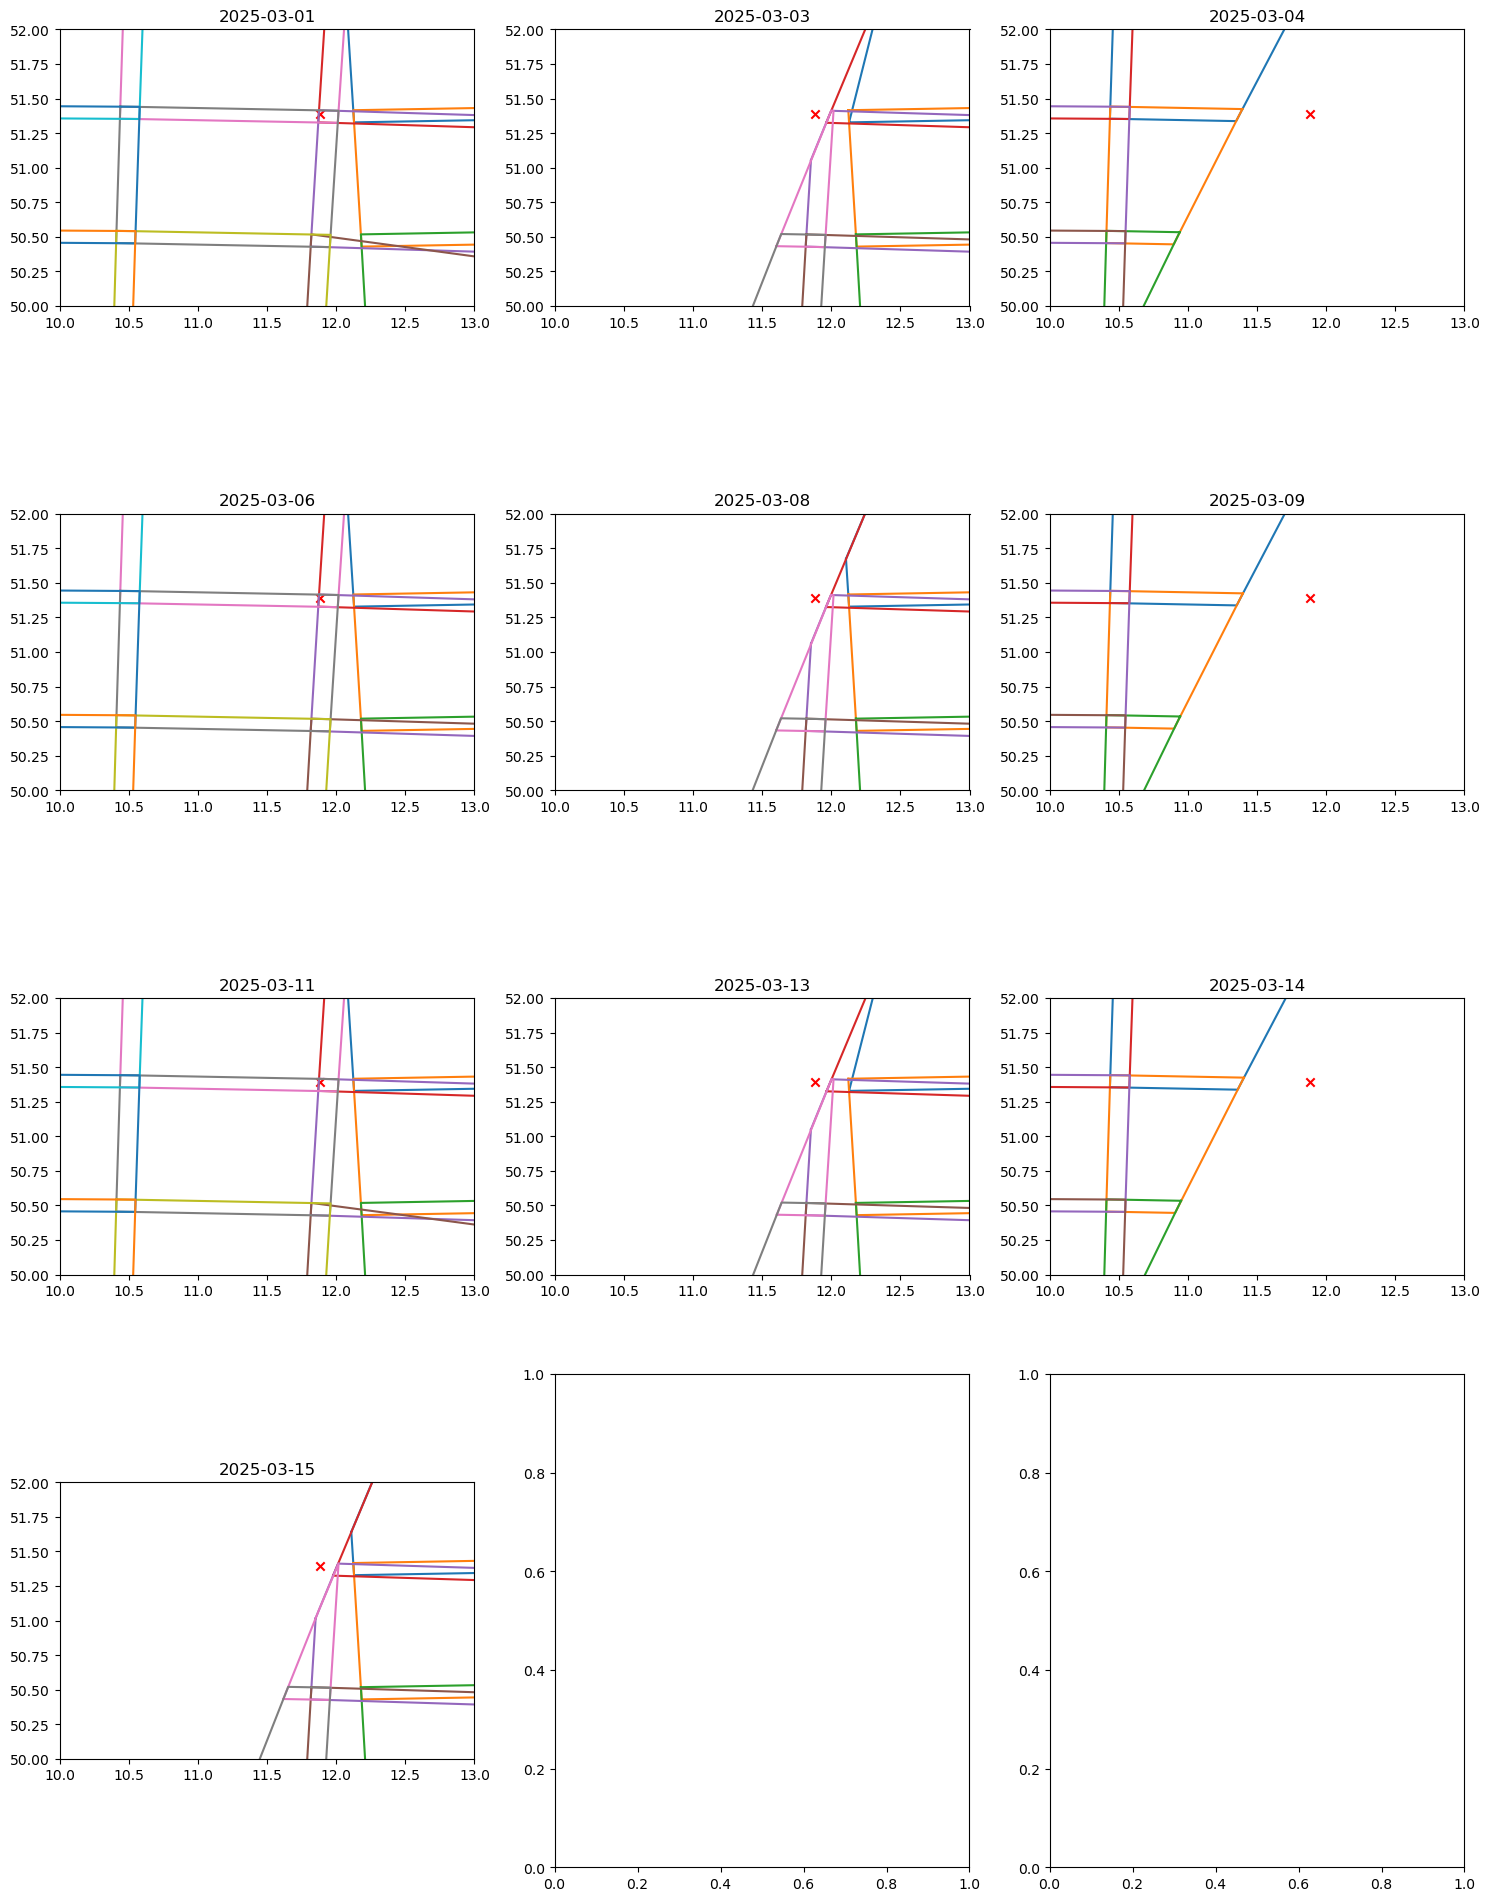

In [7]:
# --- Group items by date ---
items_by_date = {}
for item in items:
    date = item.datetime.date()
    items_by_date.setdefault(date, []).append(item)

# --- Plot ---
n_dates = len(items_by_date)
cols = 3
rows = math.ceil(n_dates / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for ax, (date, date_items) in zip(axes, sorted(items_by_date.items())):
    for item in date_items:
        geom = shape(item.geometry)
        geom_x, geom_y = geom.exterior.xy
        ax.plot(geom_x, geom_y)
    ax.scatter(lon, lat, marker="x", color="red")
    ax.set_title(str(date))
    ax.set_aspect("equal")
    ax.set_ylim(bbox[1], bbox[3])
    ax.set_xlim(bbox[0], bbox[2])

plt.tight_layout()
plt.show()